# EDA: Breast Cancer Wisconsin

Разведочный анализ датасета перед экспериментами с классификацией (см. `02_logreg_baseline` и `03_gradient_boosting`).

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from ml_toolkit.data import load_dataset

In [2]:
X, y, names = load_dataset("breast_cancer")
df = pd.DataFrame(X, columns=names)
df["target"] = y
print(df.shape)

(569, 31)


## Баланс классов

`target = 0` — злокачественная опухоль, `target = 1` — доброкачественная.

In [3]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Связь признаков с таргетом

In [4]:
corr = df.corr()["target"].drop("target").sort_values()
corr.head(5)

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
Name: target, dtype: float64

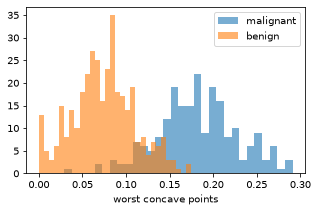

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
for cls, label in [(0, "malignant"), (1, "benign")]:
    ax.hist(df.loc[df.target == cls, "worst concave points"], bins=30, alpha=0.6, label=label)
ax.set_xlabel("worst concave points")
ax.legend()
plt.show()

**Вывод:** классы умеренно несбалансированы, поэтому дальше используем стратифицированное разбиение и смотрим не только на accuracy, но и на F1 и ROC-AUC. Признаки формы опухоли (concave points, perimeter, radius) сильнее всего отрицательно коррелируют с таргетом.